## Ejemplo SVM Clasificación no lineal
<div style="border-style:groove;border-width:thin;padding:10px">
En la clase anterior hemos visto un ejemplo de clasificación lineal utilizando SVM. Se usó el método LinearSVC de Scikit-Learn. Hoy vamos a ver como sería una clasificación no lineal, es decir, cuando la frontera o fronteras de decisión entre las clases no son rectas.
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
Una posible solución es generar nuevos datos de orden superior como hicimos con la regresión, sin embargo, esta solución no es generalizable con datasets grandes o con un grado alto. Por ello vamos a probar una solución más específica.
   </div>

<div style="border-style:groove;border-width:thin;padding:10px">
Debes seguir los siguientes pasos:
    <ol>
        <li>Importa el dataset make_moons que sirve para generar puntos de semicírculos intercalados. Genera X e y con la orden "X,y = make_moons(n_samples=1000,noise =0.3)".</li>
        <li>Pinta los datos con colores distintos para y=0 e y=1 usando scatter</li>
        <li>Modifica los parámetros de make_moons n_samples y noise y analiza el resultado.</li>
        <li>Genera el objeto clasificador de "Support Vectors"  con la orden "SVC(kernel='poly',degree=3,coef0=1,C=5)". kernel=poly indica que la solución va a ser polinomial.</li>
        <li>Genera los conjutos de train y de test y entrena el sistema.</li>
        <li>Saca el classification report y modifica los parámetros del SVC para ver si cambia el resultado. Prueba a poner una solución lineal (kernel='linear'), a cambiar el grado del polinomio y a cambiar el C.</li>
    </ol>
    <p>En este ejercicio hemos utilizado la clase SVC. Tenéis más información aquí:</p>
    <a>https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html</a>
</div>

In [130]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#1
X,y = make_moons(n_samples=20000,noise=0.3, random_state=42)

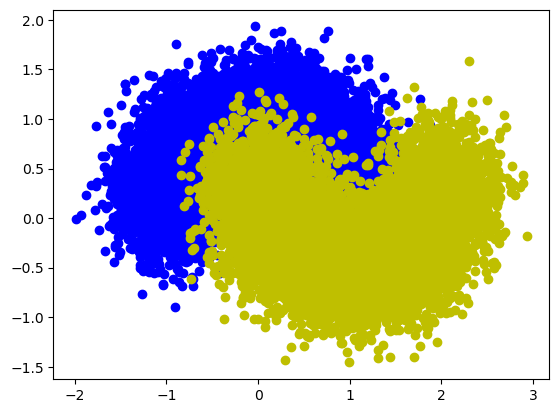

In [131]:
import numpy as np
ceros = []
unos = []
import matplotlib.pyplot as plt
for i,clase in enumerate(y):
    if clase == 0:
        ceros.append([X[:,0][i],X[:,1][i]])
    else:
        unos.append([X[:,0][i],X[:,1][i]])
ceros = np.array(ceros)
unos = np.array(unos)
plt.scatter(ceros[:,0],ceros[:,1],color='b')
plt.scatter(unos[:,0],unos[:,1],color='y')
plt.show()

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [133]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
# C = 1 es el valor por defecto en scikit-learn.
# Funciona bien como referencia.
# Permite mostrar que una SVM lineal no es suficiente en datos no lineales.
#svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_poly = SVC(kernel="poly", degree=4, coef0=1, C=5.0)

#svm_lineal.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)

SVC(C=5.0, coef0=1, degree=4, kernel='poly')

In [135]:
#pred_lineal = svm_lineal.predict(X_test_scaled)
pred_rbf = svm_poly.predict(X_test_scaled)

"""print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) #exactitud
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))"""

print("\n=== SVM RBF ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))


=== SVM RBF ===
Accuracy: 0.914
[[2287  213]
 [ 217 2283]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2500
           1       0.91      0.91      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



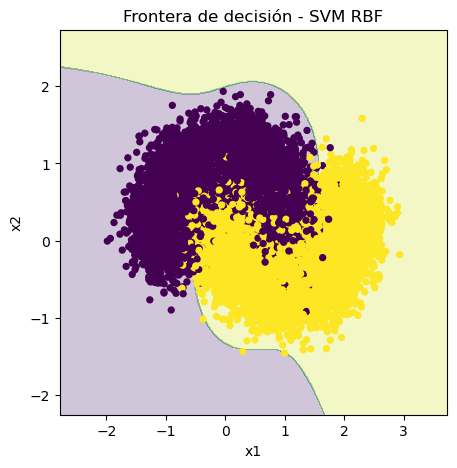

In [136]:
def plot_decision_boundary(model, scaler, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

#plot_decision_boundary(svm_lineal, scaler, X, y, "Frontera de decisión - SVM Lineal")
plot_decision_boundary(svm_poly, scaler, X, y, "Frontera de decisión - SVM RBF")